In [1]:
#!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys
import os

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import numerical_utils as nuti

#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF
import update_config as uc
#local utils.py
import utils as U 



# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Extra for analysis and 'loggy' levels
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors


# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers
import importlib
from pathlib import Path

# Constants
grav=Co.grav()
cp=Co.cpair()

importlib.reload(U)


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


<module 'utils' from '/glade/work/juliob/HiRes_ana_dev/Drivers/Analysis/utils.py'>

In [7]:
year,month,day,hour = 2016,8,13,12

date_=f"{year:04d}-{month:02d}-{day:02d}-{hour*3_600:05d}"
print( f"Processing MPAS 3.75km for {date_}", flush=True)
case=f"c124_dyamond1_prod2"
SrcDir = f"/glade/campaign/cesm/km-scale/archive/{case}/atm/hist"

WrkDir = f"/glade/campaign/cgd/amp/juliob/mpasa3p75km/{date_}"
TimeInvDir = f"/glade/campaign/cgd/amp/juliob/mpasa3p75km/TimeInvariant"

UHRtag='UHR_SO-Indian'
var='w_mpas_prt'

file= f"{WrkDir}/{var}_dyamond_{UHRtag}.{date_}.nc"
zfile= f"{TimeInvDir}/zgrid_dyamond_{UHRtag}.nc"



X=xr.open_dataset(file)
Zg=xr.open_dataset(zfile)


Processing MPAS 3.75km for 2016-08-13-43200


In [8]:
wp = X.w_mpas_prt.values
zgr,lat,lon = Zg.zgrid.values, X.lat.values, X.lon.values


In [11]:
nz,ny,nx = zgr.shape

In [12]:


Lon = np.broadcast_to(lon[None, :], (nz, nx))



1124 -45.003706449221646


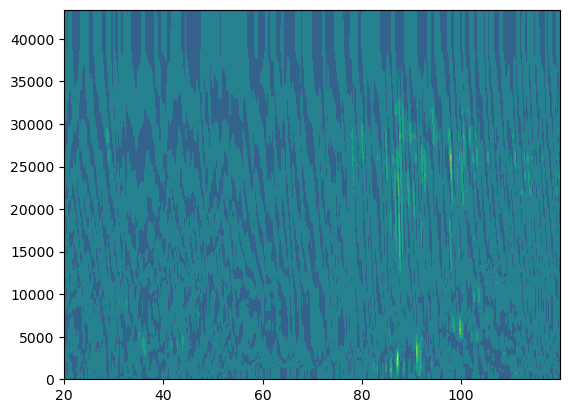

In [18]:
z0=25_000.
lat0 =-45. 
y =  np.argmin( np.abs( lat - lat0 ) )
print( y,lat[y] )


plt.contourf( Lon[:,:], zgr[:,y,:], wp[0,:,y,:] )